In [ ]:
import pandas as pd
import numpy as np
import os
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import json
import dalex as dx
from sklearn.linear_model import ElasticNet
import shap
import matplotlib.pyplot as plt

data = pd.read_csv(os.path.join("wide_sta_observations.csv"), parse_dates=["period_date"])
data.rename(columns={"period_date": "date"}, inplace=True)
metadata = pd.read_csv(os.path.join("all_metadata.csv"))

target_variable = "66" 
lags = list(range(-2, 3)) 

train_start_date = "2000-01-01"
test_start_date = "2018-03-01" 
test_end_date = "2023-12-01"

test = data.loc[
    (data.date >= train_start_date) & 
    (data.date <= test_end_date)
].reset_index(drop=True)

print(f"Duomenų rėžių patikra nuo {test.date.min()} iki {test.date.max()}")

Duomenų rėžių patikra nuo 2000-01-01 00:00:00 iki 2023-12-01 00:00:00


In [6]:
# kodas iš: https://github.com/dhopp1/nowcasting_benchmark/tree/main/methodologies

# Generuojami suvėlinti duomenų rinkiniai testavimui pagal informacijos prieinamumo laikotarpius (vintages)
def gen_lagged_data(metadata, data, last_date, lag):
    lagged_data = data.loc[data.date <= last_date, :].reset_index(drop=True)
    metadata['series_id'] = metadata['series_id'].astype(str)
    for col in lagged_data.columns[1:]:
        pub_lag = metadata.loc[metadata.series_id == col, "months_lag"].values[0] # Konkretaus kintamojo paskelbimo vėlavimas
        # Reikšmės paslepiamos (NaN) atsižvelgiant į paskelbimo vėlavimą ir pasirinktą modeliavimo momentą (lag)
        lagged_data.loc[(len(lagged_data) - pub_lag + lag) :, col] = np.nan

    return lagged_data

# Ankstenių mėnesių reikšmių įtraukimas (kaip atskiri kintamieji)
def flatten_data(data, target_variable, n_lags):
    flattened_data = data.loc[~pd.isna(data[target_variable]), :]
    orig_index = flattened_data.index
    for i in range(1, n_lags + 1):
        lagged_indices = orig_index - i
        lagged_indices = lagged_indices[lagged_indices >= 0]
        tmp = data.loc[lagged_indices, :]
        tmp.date = tmp.date + pd.DateOffset(months=i)
        tmp = tmp.drop([target_variable], axis=1)
        tmp.columns = [j + "_" + str(i) if j != "date" else j for j in tmp.columns]
        flattened_data = flattened_data.merge(tmp, how="left", on="date")

    return flattened_data

# Praleistų reikšmių užpildymas naudojant mokymo rinkinio vidurkį
def mean_fill_dataset(training, test):
    mean_dict = {}
    for col in training.columns[1:]:
        mean_dict[col] = np.nanmean(training[col])
    filled = test.copy()
    for col in training.columns[1:]:
        filled.loc[pd.isna(filled[col]), col] = mean_dict[col]
    return filled

In [7]:
kintamuju_zodynas = {
    1: "Pramonė: gavyba",
    2: "Pramonė: gamyba",
    3: "Pramonė: energetika ir komunalinės paslaugos",
    4: "Importas (EZ)",
    5: "Eksportas (EZ)",
    6: "SVKI: bendras indeksas",
    7: "SVKI: maistas ir nealkoholiniai gėrimai",
    8: "SVKI: alkoholis ir tabakas",
    9: "SVKI: drabužiai ir avalynė",
    10: "SVKI: būstas ir komunalinės paslaugos",
    11: "SVKI: būsto apstatymas ir priežiūra",
    12: "SVKI: sveikatos apsauga",
    13: "SVKI: transportas",
    14: "SVKI: ryšiai",
    15: "SVKI: poilsis ir kultūra",
    16: "SVKI: švietimas",
    17: "SVKI: viešbučiai ir restoranai",
    18: "SVKI: įvairios prekės ir paslaugos",
    19: "SVKI: prekės (be paslaugų)",
    20: "SVKI: maistas, alkoholis, tabakas",
    21: "SVKI: pramoninės prekės",
    22: "SVKI: energetika",
    23: "SVKI: elektra, dujos, kietasis kuras ir šiluma",
    24: "SVKI: degalai ir tepalai",
    25: "SVKI: paslaugos (be prekių)",
    26: "SVKI: administruojamos kainos",
    27: "SVKI: visiškai administruojamos kainos",
    28: "SVKI: daugiausia administruojamos kainos",
    29: "EPS konvergencijos kriterijai",
    30: "Nedarbo lygis",
    31: "Pinigų rinkos palūkanų normos",
    32: "EZ pajamingumo kreivės",
    33: "Prekybos apyvarta ir pardavimų apimtis",
    34: "EUR/USD valiutos kursas",
    35: "Pramonės pasitikėjimas: gamyba (praėję 3 mėn.)",
    36: "Pramonės pasitikėjimas: užimtumo lūkesčiai (ateityje 3 mėn.)",
    37: "Pramonės pasitikėjimas: užsakymų lygis",
    38: "Pramonės pasitikėjimas: eksporto užsakymai",
    39: "Pramonės pasitikėjimas: produkcijos atsargos",
    40: "Pramonės pasitikėjimas: gamybos lūkesčiai (ateityje 3 mėn.)",
    41: "Statybų pasitikėjimas: užimtumo lūkesčiai (ateityje 3 mėn.)",
    42: "Statybų pasitikėjimas: statybos aktyvumas (praėję 3 mėn.)",
    43: "Statybų pasitikėjimas: užsakymų knyga",
    44: "Statybų pasitikėjimas: kainų lūkesčiai (ateityje 3 mėn.)",
    45: "Statybų pasitikėjimo indeksas",
    46: "Mažmeninės prekybos pasitikėjimas: pardavimai (praėję 3 mėn.)",
    47: "Mažmeninės prekybos pasitikėjimas: atsargų kiekis",
    48: "Mažmeninės prekybos pasitikėjimas: užsakymai tiekėjams (ateityje 3 mėn.)",
    49: "Mažmeninės prekybos pasitikėjimas: veiklos lūkesčiai (ateityje 3 mėn.)",
    50: "Mažmeninės prekybos pasitikėjimas: užimtumo lūkesčiai (ateityje 3 mėn.)",
    51: "Verslo klimato indeksas (EZ)",
    52: "Ekonominis sentimentas: statybų pasitikėjimas",
    53: "Ekonominio sentimento indeksas (ESI)",
    54: "Ekonominis sentimentas: pramonės pasitikėjimas",
    55: "Ekonominis sentimentas: mažmeninės prekybos pasitikėjimas",
    56: "Ekonominis sentimentas: vartotojų pasitikėjimas",
    57: "Vartotojų pasitikėjimas: finansinė padėtis (praėję 12 mėn.)",
    58: "Vartotojų pasitikėjimas: finansinė padėtis (ateityje 12 mėn.)",
    59: "Vartotojų pasitikėjimas: ekonominė situacija (praėję 12 mėn.)",
    60: "Vartotojų pasitikėjimas: ekonominė situacija (ateityje 12 mėn.)",
    61: "Vartotojų pasitikėjimas: kainų tendencijos (praėję 12 mėn.)",
    62: "Vartotojų pasitikėjimas: kainų tendencijos (ateityje 12 mėn.)",
    63: "Vartotojų pasitikėjimas: nedarbo lūkesčiai (ateityje 12 mėn.)",
    64: "Vartotojų pasitikėjimas: didesni pirkiniai (ateityje 12 mėn.)",
    65: "Vartotojų pasitikėjimas: taupymas (ateityje 12 mėn.)",
    66: "Bendrasis vidaus produktas (BVP)",
    67: "Pajamingumo skirtumas (10 met. - 3 mėn.)",
    68: "Paskolos namų ūkiams: vartojimui (metinis augimas)",
    69: "Paskolos namų ūkiams: būstui (metinis augimas)",
    70: "Paskolos namų ūkiams: kitos paskolos (metinis augimas)",
    71: "Paskolos namų ūkiams: iš viso (metinis augimas)",
    72: "Paskolos nefinansinėms korporacijoms (metinis augimas)",
    73: "Indėliai: finansinės korporacijos (metinis augimas)",
    74: "Indėliai: namų ūkiai (metinis augimas)",
    75: "Indėliai: nefinansinės korporacijos (metinis augimas)",
    76: "Terminuotieji indėliai: namų ūkiai (metinis augimas)",
    77: "Vienadieniai indėliai: namų ūkiai (metinis augimas)",
    78: "Vienadieniai indėliai: nefinansinėskorporacijos (metinis augimas)",
    79: "Skolinimosi kaina: namų ūkių būstui",
    80: "Skolinimosi kaina: korporacijoms",
    81: "Palūkanų normos: paskolos namų ūkiams vartojimui",
    82: "Palūkanų normos: atnaujinamos paskolos ir kredito kortelės namų ūkiams",
    83: "Skolinimosi kaina: naujos trumpalaikės paskolos",
    84: "Skolinimosi kaina: naujos ilgalaikės paskolos",
    85: "Palūkanų normos: namų ūkių vienadieniai indėliai",
    86: "Palūkanų normos: korporacijų vienadieniai indėliai",
    87: "Palūkanų normos: namų ūkių indėliai iki 1 metų",
    88: "Palūkanų normos: korporacijų indėliai iki 1 metų",
    89: "Palūkanų normos: indėliai su įspėjamuoju laikotarpiu iki 3 mėn.",
    90: "Prekių balansas",
    91: "Paslaugų balansas",
    92: "Pirminių pajamų balansas",
    93: "Antrinių pajamų balansas",
    94: "Finansinė sąskaita: tiesioginės investicijos (grynosios)",
    95: "Finansinė sąskaita: portfelinės investicijos (grynosios)",
    96: "Finansinė sąskaita: kitos investicijos (grynosios)",
    97: "Akcijų atsargos: Lietuvos ekonomika",
    98: "Akcijų fondų turtas",
    99: "Obligacijų fondų turtas",
    100: "Nekilnojamojo turto fondų turtas",
    101: "Kitų fondų turtas"
}

def build_variable_groups(columns):
    id_to_group = {
        # Pramonės gamyba
        1:  "Pramonės gamyba",
        2:  "Pramonės gamyba",
        3:  "Pramonės gamyba",
        # Užsienio prekyba ir makroekonominiai rodikliai
        4:  "Užsienio prekyba ir makroekonominiai rodikliai",
        5:  "Užsienio prekyba ir makroekonominiai rodikliai",
        30: "Užsienio prekyba ir makroekonominiai rodikliai",
        33: "Užsienio prekyba ir makroekonominiai rodikliai",
        34: "Užsienio prekyba ir makroekonominiai rodikliai",
        67: "Užsienio prekyba ir makroekonominiai rodikliai",
        # SVKI: bendrieji komponentai
        6:  "SVKI: bendrieji komponentai",
        7:  "SVKI: bendrieji komponentai",
        8:  "SVKI: bendrieji komponentai",
        9:  "SVKI: bendrieji komponentai",
        11: "SVKI: bendrieji komponentai",
        12: "SVKI: bendrieji komponentai",
        16: "SVKI: bendrieji komponentai",
        19: "SVKI: bendrieji komponentai",
        20: "SVKI: bendrieji komponentai",
        21: "SVKI: bendrieji komponentai",
        # SVKI: energetika ir administruojamos kainos
        10: "SVKI: energetika ir administruojamos kainos",
        22: "SVKI: energetika ir administruojamos kainos",
        23: "SVKI: energetika ir administruojamos kainos",
        24: "SVKI: energetika ir administruojamos kainos",
        26: "SVKI: energetika ir administruojamos kainos",
        27: "SVKI: energetika ir administruojamos kainos",
        28: "SVKI: energetika ir administruojamos kainos",
        # SVKI: paslaugos
        13: "SVKI: paslaugos",
        14: "SVKI: paslaugos",
        15: "SVKI: paslaugos",
        17: "SVKI: paslaugos",
        18: "SVKI: paslaugos",
        25: "SVKI: paslaugos",
        # Pramonės pasitikėjimas
        35: "Pramonės pasitikėjimas",
        36: "Pramonės pasitikėjimas",
        37: "Pramonės pasitikėjimas",
        38: "Pramonės pasitikėjimas",
        39: "Pramonės pasitikėjimas",
        40: "Pramonės pasitikėjimas",
        # Statybų pasitikėjimas
        41: "Statybų pasitikėjimas",
        42: "Statybų pasitikėjimas",
        43: "Statybų pasitikėjimas",
        44: "Statybų pasitikėjimas",
        45: "Statybų pasitikėjimas",
        # Vartotojų pasitikėjimas
        56: "Vartotojų pasitikėjimas",
        57: "Vartotojų pasitikėjimas",
        58: "Vartotojų pasitikėjimas",
        59: "Vartotojų pasitikėjimas",
        60: "Vartotojų pasitikėjimas",
        61: "Vartotojų pasitikėjimas",
        62: "Vartotojų pasitikėjimas",
        63: "Vartotojų pasitikėjimas",
        64: "Vartotojų pasitikėjimas",
        65: "Vartotojų pasitikėjimas",
        # Mažmeninės prekybos pasitikėjimas
        46: "Mažmeninės prekybos pasitikėjimas",
        47: "Mažmeninės prekybos pasitikėjimas",
        48: "Mažmeninės prekybos pasitikėjimas",
        49: "Mažmeninės prekybos pasitikėjimas",
        50: "Mažmeninės prekybos pasitikėjimas",
        # Ekonominis sentimentas
        51: "Ekonominis sentimentas",
        52: "Ekonominis sentimentas",
        53: "Ekonominis sentimentas",
        54: "Ekonominis sentimentas",
        55: "Ekonominis sentimentas",
        # Pinigų rinka ir kreditas
        29: "Pinigų rinka ir kreditas",
        31: "Pinigų rinka ir kreditas",
        32: "Pinigų rinka ir kreditas",
        68: "Pinigų rinka ir kreditas",
        69: "Pinigų rinka ir kreditas",
        70: "Pinigų rinka ir kreditas",
        71: "Pinigų rinka ir kreditas",
        72: "Pinigų rinka ir kreditas",
        73: "Pinigų rinka ir kreditas",
        74: "Pinigų rinka ir kreditas",
        75: "Pinigų rinka ir kreditas",
        76: "Pinigų rinka ir kreditas",
        77: "Pinigų rinka ir kreditas",
        78: "Pinigų rinka ir kreditas",
        79: "Pinigų rinka ir kreditas",
        80: "Pinigų rinka ir kreditas",
        81: "Pinigų rinka ir kreditas",
        82: "Pinigų rinka ir kreditas",
        83: "Pinigų rinka ir kreditas",
        84: "Pinigų rinka ir kreditas",
        85: "Pinigų rinka ir kreditas",
        86: "Pinigų rinka ir kreditas",
        87: "Pinigų rinka ir kreditas",
        88: "Pinigų rinka ir kreditas",
        89: "Pinigų rinka ir kreditas",
        # Mokėjimų balansas
        90: "Mokėjimų balansas",
        91: "Mokėjimų balansas",
        92: "Mokėjimų balansas",
        93: "Mokėjimų balansas",
        94: "Mokėjimų balansas",
        95: "Mokėjimų balansas",
        96: "Mokėjimų balansas",
        # Finansų rinkos
        97:  "Finansų rinkos",
        98:  "Finansų rinkos",
        99:  "Finansų rinkos",
        100: "Finansų rinkos",
        101: "Finansų rinkos",
    }
    groups = {}
    for col in columns:
        parts = str(col).split('_')
        try:
            base_id = int(parts[0])
            group = id_to_group.get(base_id, "Kita")
        except ValueError:
            group = "Kita"
        if group not in groups:
            groups[group] = []
        groups[group].append(col)
    return groups



In [8]:
from collections import defaultdict

id_to_group = {
    # Pramonės gamyba
    1:  "Pramonės gamyba",
    2:  "Pramonės gamyba",
    3:  "Pramonės gamyba",
    # Užsienio prekyba ir makroekonominiai rodikliai
    4:  "Užsienio prekyba ir makroekonominiai rodikliai",
    5:  "Užsienio prekyba ir makroekonominiai rodikliai",
    30: "Užsienio prekyba ir makroekonominiai rodikliai",
    33: "Užsienio prekyba ir makroekonominiai rodikliai",
    34: "Užsienio prekyba ir makroekonominiai rodikliai",
    67: "Užsienio prekyba ir makroekonominiai rodikliai",
    # SVKI: bendrieji komponentai
    6:  "SVKI: bendrieji komponentai",
    7:  "SVKI: bendrieji komponentai",
    8:  "SVKI: bendrieji komponentai",
    9:  "SVKI: bendrieji komponentai",
    11: "SVKI: bendrieji komponentai",
    12: "SVKI: bendrieji komponentai",
    16: "SVKI: bendrieji komponentai",
    19: "SVKI: bendrieji komponentai",
    20: "SVKI: bendrieji komponentai",
    21: "SVKI: bendrieji komponentai",
    # SVKI: energetika ir administruojamos kainos
    10: "SVKI: energetika ir administruojamos kainos",
    22: "SVKI: energetika ir administruojamos kainos",
    23: "SVKI: energetika ir administruojamos kainos",
    24: "SVKI: energetika ir administruojamos kainos",
    26: "SVKI: energetika ir administruojamos kainos",
    27: "SVKI: energetika ir administruojamos kainos",
    28: "SVKI: energetika ir administruojamos kainos",
    # SVKI: paslaugos
    13: "SVKI: paslaugos",
    14: "SVKI: paslaugos",
    15: "SVKI: paslaugos",
    17: "SVKI: paslaugos",
    18: "SVKI: paslaugos",
    25: "SVKI: paslaugos",
    # Pramonės pasitikėjimas
    35: "Pramonės pasitikėjimas",
    36: "Pramonės pasitikėjimas",
    37: "Pramonės pasitikėjimas",
    38: "Pramonės pasitikėjimas",
    39: "Pramonės pasitikėjimas",
    40: "Pramonės pasitikėjimas",
    # Statybų pasitikėjimas
    41: "Statybų pasitikėjimas",
    42: "Statybų pasitikėjimas",
    43: "Statybų pasitikėjimas",
    44: "Statybų pasitikėjimas",
    45: "Statybų pasitikėjimas",
    # Vartotojų pasitikėjimas
    56: "Vartotojų pasitikėjimas",
    57: "Vartotojų pasitikėjimas",
    58: "Vartotojų pasitikėjimas",
    59: "Vartotojų pasitikėjimas",
    60: "Vartotojų pasitikėjimas",
    61: "Vartotojų pasitikėjimas",
    62: "Vartotojų pasitikėjimas",
    63: "Vartotojų pasitikėjimas",
    64: "Vartotojų pasitikėjimas",
    65: "Vartotojų pasitikėjimas",
    # Mažmeninės prekybos pasitikėjimas
    46: "Mažmeninės prekybos pasitikėjimas",
    47: "Mažmeninės prekybos pasitikėjimas",
    48: "Mažmeninės prekybos pasitikėjimas",
    49: "Mažmeninės prekybos pasitikėjimas",
    50: "Mažmeninės prekybos pasitikėjimas",
    # Ekonominis sentimentas
    51: "Ekonominis sentimentas",
    52: "Ekonominis sentimentas",
    53: "Ekonominis sentimentas",
    54: "Ekonominis sentimentas",
    55: "Ekonominis sentimentas",
    # Pinigų rinka ir kreditas
    29: "Pinigų rinka ir kreditas",
    31: "Pinigų rinka ir kreditas",
    32: "Pinigų rinka ir kreditas",
    68: "Pinigų rinka ir kreditas",
    69: "Pinigų rinka ir kreditas",
    70: "Pinigų rinka ir kreditas",
    71: "Pinigų rinka ir kreditas",
    72: "Pinigų rinka ir kreditas",
    73: "Pinigų rinka ir kreditas",
    74: "Pinigų rinka ir kreditas",
    75: "Pinigų rinka ir kreditas",
    76: "Pinigų rinka ir kreditas",
    77: "Pinigų rinka ir kreditas",
    78: "Pinigų rinka ir kreditas",
    79: "Pinigų rinka ir kreditas",
    80: "Pinigų rinka ir kreditas",
    81: "Pinigų rinka ir kreditas",
    82: "Pinigų rinka ir kreditas",
    83: "Pinigų rinka ir kreditas",
    84: "Pinigų rinka ir kreditas",
    85: "Pinigų rinka ir kreditas",
    86: "Pinigų rinka ir kreditas",
    87: "Pinigų rinka ir kreditas",
    88: "Pinigų rinka ir kreditas",
    89: "Pinigų rinka ir kreditas",
    # Mokėjimų balansas
    90: "Mokėjimų balansas",
    91: "Mokėjimų balansas",
    92: "Mokėjimų balansas",
    93: "Mokėjimų balansas",
    94: "Mokėjimų balansas",
    95: "Mokėjimų balansas",
    96: "Mokėjimų balansas",
    # Finansų rinkos
    97:  "Finansų rinkos",
    98:  "Finansų rinkos",
    99:  "Finansų rinkos",
    100: "Finansų rinkos",
    101: "Finansų rinkos",
}


group_to_ids = defaultdict(list)
for bid, grp in id_to_group.items():
    group_to_ids[grp].append(bid)

# Išsispausdiname grupes
for group, ids in group_to_ids.items():
    print(f"\n{group} ({len(ids)} baziniai kintamieji):")
    for bid in sorted(ids):
        print(f"  [{bid}] {kintamuju_zodynas.get(bid, '?')}")


Pramonės gamyba (3 baziniai kintamieji):
  [1] Pramonė: gavyba
  [2] Pramonė: gamyba
  [3] Pramonė: energetika ir komunalinės paslaugos

Užsienio prekyba ir makroekonominiai rodikliai (6 baziniai kintamieji):
  [4] Importas (EZ)
  [5] Eksportas (EZ)
  [30] Nedarbo lygis
  [33] Prekybos apyvarta ir pardavimų apimtis
  [34] EUR/USD valiutos kursas
  [67] Pajamingumo skirtumas (10 met. - 3 mėn.)

SVKI: bendrieji komponentai (10 baziniai kintamieji):
  [6] SVKI: bendras indeksas
  [7] SVKI: maistas ir nealkoholiniai gėrimai
  [8] SVKI: alkoholis ir tabakas
  [9] SVKI: drabužiai ir avalynė
  [11] SVKI: būsto apstatymas ir priežiūra
  [12] SVKI: sveikatos apsauga
  [16] SVKI: švietimas
  [19] SVKI: prekės (be paslaugų)
  [20] SVKI: maistas, alkoholis, tabakas
  [21] SVKI: pramoninės prekės

SVKI: energetika ir administruojamos kainos (7 baziniai kintamieji):
  [10] SVKI: būstas ir komunalinės paslaugos
  [22] SVKI: energetika
  [23] SVKI: elektra, dujos, kietasis kuras ir šiluma
  [24] SVKI

In [9]:
test = data.loc[
    (data.date >= train_start_date) & 
    (data.date <= test_end_date)
].reset_index(drop=True)

dates = (
        pd.date_range(test_start_date, test_end_date, freq="3MS")
        .strftime("%Y-%m-%d")
        .tolist()
    )

actuals = list(test.loc[test.date.isin(dates), target_variable].values)

train_data = test.loc[test.date < test_start_date].copy()

# Kuriame kintamųjų matricą (n_lags skaičius pagal geriausią rezultatą)
df_flat = flatten_data(train_data, target_variable, n_lags=5) 
df_model = df_flat.loc[df_flat.date.dt.month.isin([3, 6, 9, 12]), :].dropna(subset=[target_variable])

X_train = df_model.drop(["date", target_variable], axis=1).dropna(axis=1, how='all')
y_train = df_model[target_variable]

C:\Users\MigleV\AppData\Local\Temp\ipykernel_19624\705088508.py:12: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  actuals = list(test.loc[test.date.isin(dates), target_variable].values)


# Modelių prognozių palyginimas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from dm_test import dm_test

df_arma = pd.read_csv('arma/predictions_arma.csv')
df_enet = pd.read_csv('elasticnet/predictions_elasticnet.csv')
df_xgb = pd.read_csv('xgboost/predictions_xgboost.csv')

# dm_test funkcija reikalauja list formato
actuals = df_arma['actual'].tolist()
lags = [-2, -1, 0, 1, 2]

results = []

# Lyginame modelius pagal informacijos prieinamumo laikotarpį
for lag in lags:
    h = 1    # visada prognozuojamas tas pats ketvirtis, tik skiriasi turimos informacijos kiekis
    
    pred_arma = df_arma[f'lag_{lag}'].tolist()
    pred_enet = df_enet[f'lag_{lag}'].tolist()
    pred_xgb = df_xgb[f'lag_{lag}'].tolist()
    
    # Atliekame testus (kriterijus MSE)
    dm_enet = dm_test(actuals, pred_arma, pred_enet, h=h, crit="MSE")
    dm_xgb = dm_test(actuals, pred_arma, pred_xgb, h=h, crit="MSE")
    
    # Saugome rezultatus
    results.append({
        'Lag': lag,
        'Comparison': 'ARMA vs ElasticNet',
        'DM_Stat': round(dm_enet.DM, 4),
        'p_value': round(dm_enet.p_value, 4),
        'Significant': dm_enet.p_value < 0.05
    })
    
    results.append({
        'Lag': lag,
        'Comparison': 'ARMA vs XGBoost',
        'DM_Stat': round(dm_xgb.DM, 4),
        'p_value': round(dm_xgb.p_value, 4),
        'Significant': dm_xgb.p_value < 0.05
    })


# 3. Rezultatų lentelė
df_results = pd.DataFrame(results)
display(df_results)

,Lag,Comparison,DM_Stat,p_value,Significant
0,-2,ARMA vs ElasticNet,2.0176,0.0554,False
1,-2,ARMA vs XGBoost,0.2940,0.7714,False
2,-1,ARMA vs ElasticNet,2.2609,0.0335,True
3,-1,ARMA vs XGBoost,0.8340,0.4129,False
4,0,ARMA vs ElasticNet,1.9575,0.0625,False
5,0,ARMA vs XGBoost,1.5153,0.1433,False
6,1,ARMA vs ElasticNet,1.9040,0.0695,False
7,1,ARMA vs XGBoost,1.9168,0.0678,False
8,2,ARMA vs ElasticNet,1.8931,0.0710,False
9,2,ARMA vs XGBoost,1.9149,0.0680,False


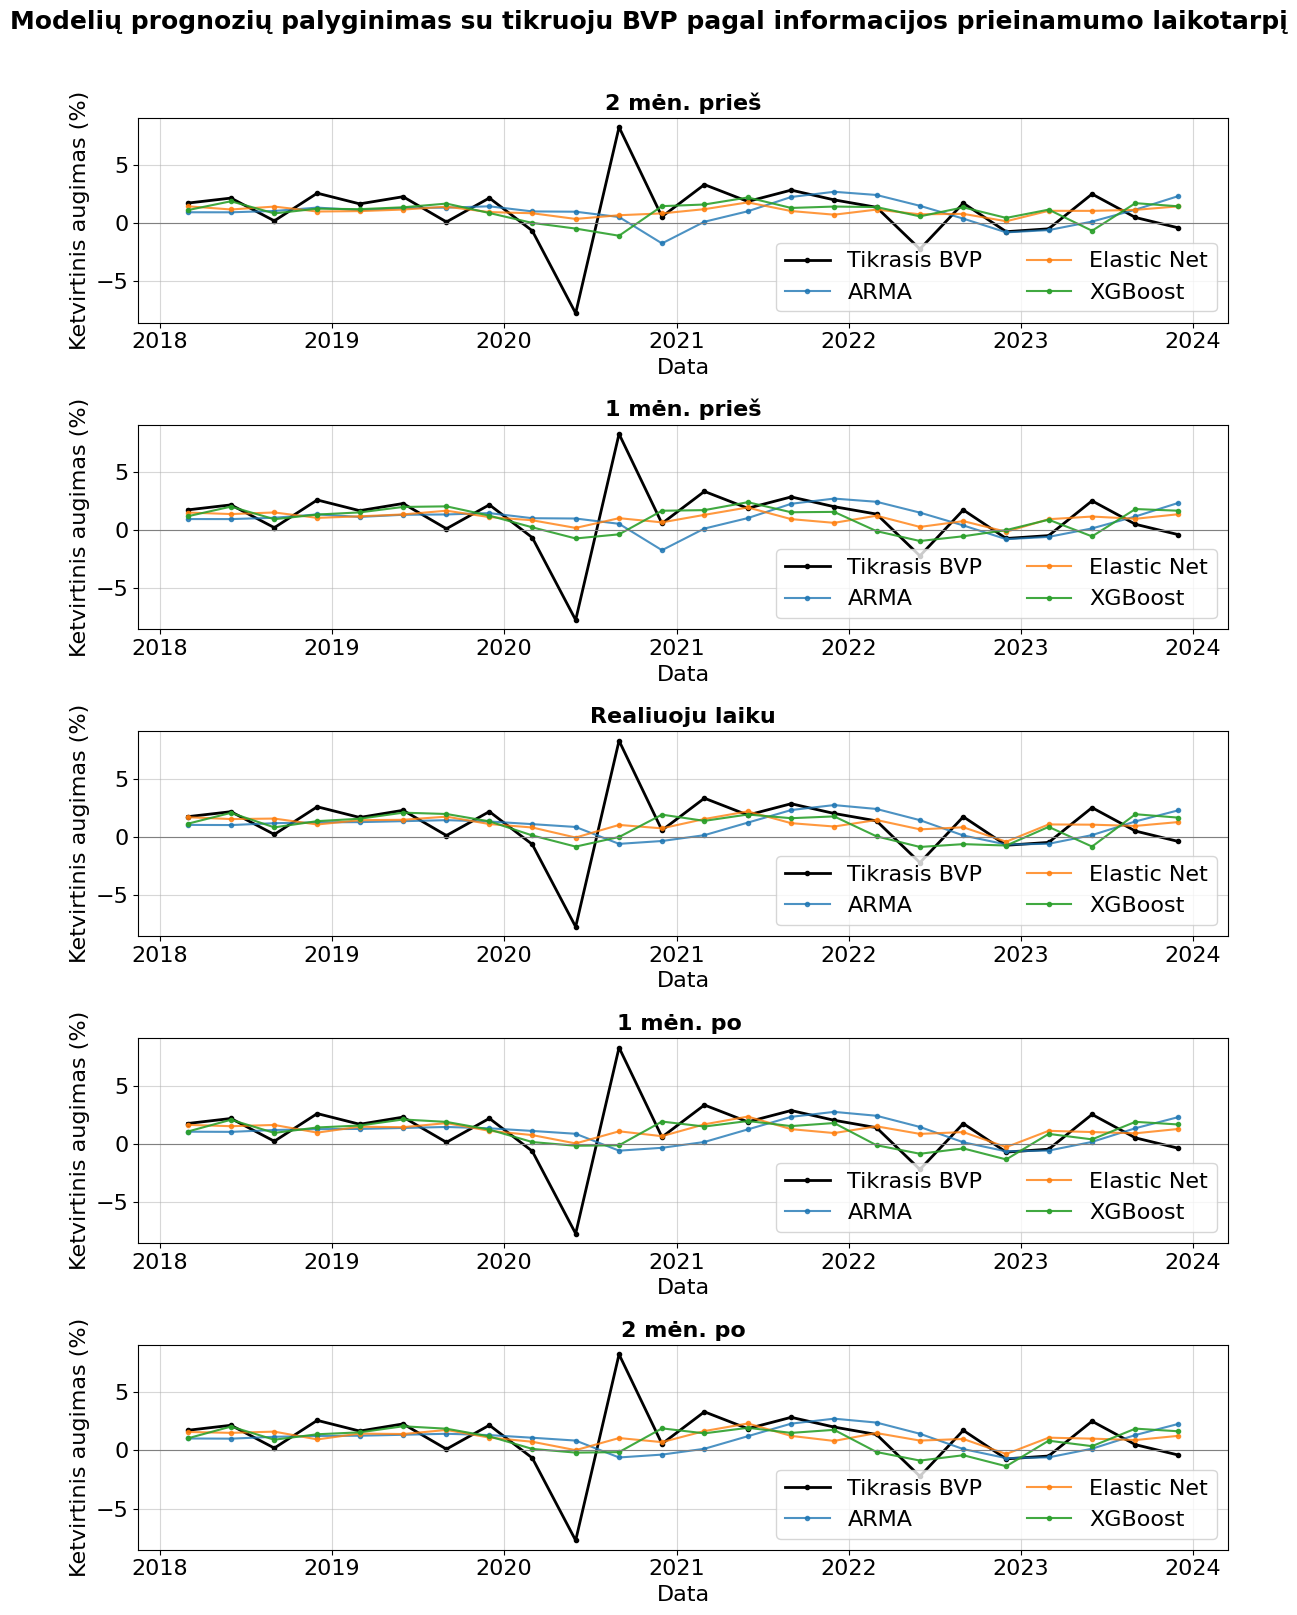

In [29]:
dates = pd.to_datetime(df_arma['date'])

lag_labels = {
    -2: "2 mėn. prieš",
    -1: "1 mėn. prieš",
     0: "Realiuoju laiku",
     1: "1 mėn. po ",
     2: "2 mėn. po"
}

lags = [-2, -1, 0, 1, 2]

fig, axes = plt.subplots(5, 1, figsize=(12, 16))
fig.suptitle("Modelių prognozių palyginimas su tikruoju BVP pagal informacijos prieinamumo laikotarpį", 
             fontsize=18, fontweight='bold', y=1.01)

for idx, lag in enumerate(lags):
    ax = axes[idx]
    
    ax.plot(dates, df_arma['actual'], label='Tikrasis BVP', color='black', linewidth=2, marker='o', markersize=3)
    
    ax.plot(dates, df_arma[f'lag_{lag}'], label='ARMA', alpha=0.8, marker='o', markersize=3)
    ax.plot(dates, df_enet[f'lag_{lag}'], label='Elastic Net', alpha=0.8, marker='o', markersize=3)
    ax.plot(dates, df_xgb[f'lag_{lag}'], label='XGBoost', linewidth=1.5, alpha=0.9, marker='o', markersize=3)
    
    ax.set_title(f"{lag_labels[lag]}", fontsize=16, fontweight='bold')
    ax.set_ylabel("Ketvirtinis augimas (%)", fontsize=16)
    ax.set_xlabel("Data", fontsize=16)
    ax.legend(loc='lower right',ncol=2, fontsize=16)
    ax.grid(True, which='both', alpha=0.5)
    ax.axhline(0, color='gray', linewidth=0.8)
    ax.tick_params(axis='both', which='major', labelsize=16)

plt.tight_layout()
plt.savefig('model_comparison_lags.png', dpi=300, bbox_inches='tight')
plt.show()

# Elastic Net

In [ ]:
with open('elasticnet/best_params_elasticnet.json', 'r') as f:
    best_params_en = json.load(f)

optimal_n_lags_en = best_params_en.get("optimal_n_lags", 4)
enet_inner_params = best_params_en.get("best_enet_parameters", {})
clean_params_en = {k.replace('enet__', ''): v for k, v in enet_inner_params.items()}

last_date = dates[-1]
print(f"Paskutinė testavimo data: {last_date}")

train_final = test.loc[
    test.date <= str(pd.to_datetime(last_date) - pd.tseries.offsets.DateOffset(months=3))[:10], :
].copy()

transformed_final = mean_fill_dataset(train_final, train_final)
transformed_final = flatten_data(transformed_final, target_variable, optimal_n_lags_en)
transformed_final = transformed_final.loc[
    transformed_final.date.dt.month.isin([3, 6, 9, 12]), :
].dropna(subset=[target_variable]).reset_index(drop=True)

x_final = transformed_final.drop(["date", target_variable], axis=1)
y_final = transformed_final[target_variable]

final_model_en = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('enet', ElasticNet(**clean_params_en, random_state=42, max_iter=20000))
])
final_model_en.fit(x_final, y_final);

Paskutinė testavimo data: 2023-12-01


In [11]:
# Elastic net aspect objektas su dalex
imputer_en = final_model_en.named_steps['imputer']
X_final_imputed = pd.DataFrame(
    imputer_en.transform(x_final),
    index=x_final.index,
    columns=x_final.columns
)

# exp_aspect_en = dx.Explainer(final_model_en, data=X_final_imputed, y=y_final, verbose=False)
# asp_en = dx.Aspect(exp_aspect_en)

c:\Users\MigleV\Bakalauras\nowcast\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


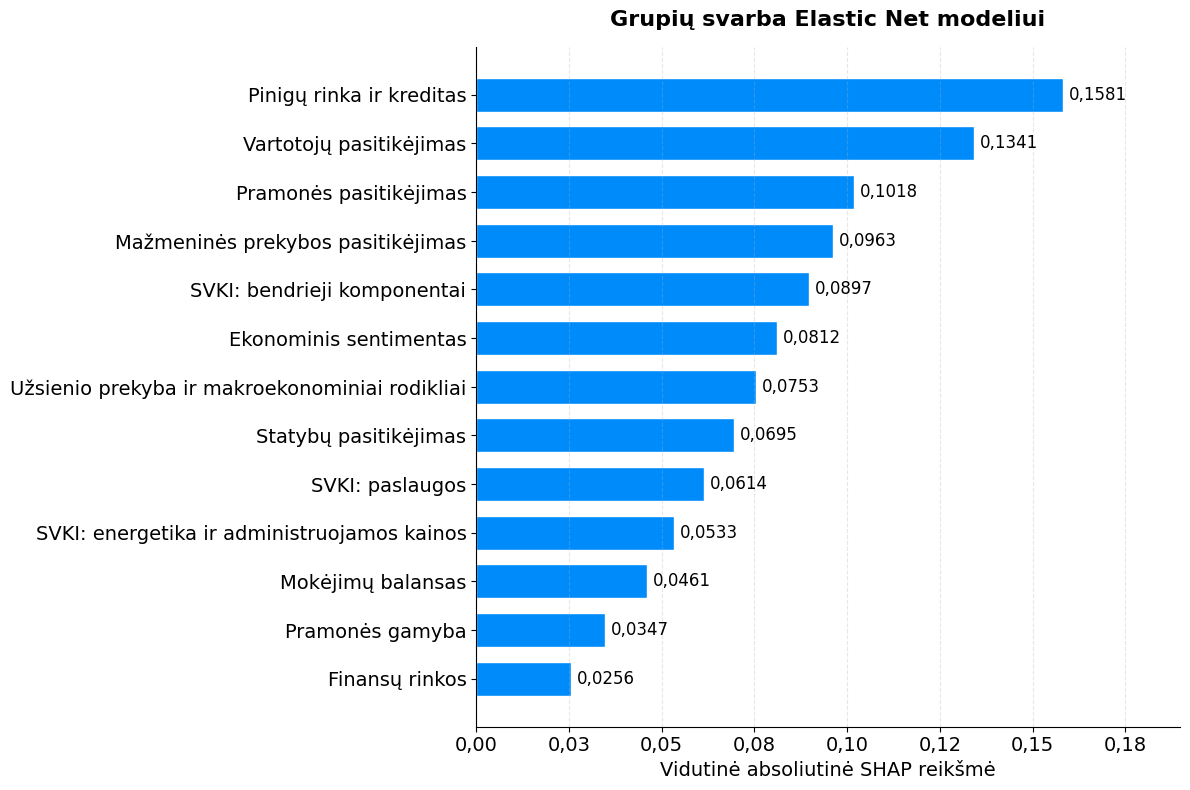

In [ ]:
# Globalios svarbos skaičiavimas SHAP
variable_groups_en = build_variable_groups(X_final_imputed.columns)

scaler_en = final_model_en.named_steps['scaler']
enet_step = final_model_en.named_steps['enet']

X_scaled_en = pd.DataFrame(
    scaler_en.transform(X_final_imputed),
    columns=X_final_imputed.columns,
    index=X_final_imputed.index
)

# LinearExplainer tiesiniams modeliams
shap_explainer_en = shap.LinearExplainer(enet_step, X_scaled_en)
shap_values_en = shap_explainer_en.shap_values(X_scaled_en)
shap_df_en = pd.DataFrame(shap_values_en, columns=X_final_imputed.columns)

# Grupės SHAP = suma narių SHAP reikšmių kiekvienam stebėjimui
# Globali svarba = vidutinė absoliutinė grupės SHAP reikšmė
group_importance_en = {}
for group_name, features in variable_groups_en.items():
    valid_features = [f for f in features if f in shap_df_en.columns]
    if not valid_features:
        continue
    group_shap = shap_df_en[valid_features].sum(axis=1)
    group_importance_en[group_name] = group_shap.abs().mean()

importance_df_en = (
    pd.Series(group_importance_en)
    .sort_values(ascending=True)
    .reset_index()
    .rename(columns={"index": "aspect_name", 0: "mean_abs_shap"})
)

# Grafikas
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(
    range(len(importance_df_en)),
    importance_df_en["mean_abs_shap"],
    color="#008BFB",
    edgecolor="white",
    height=0.7
)
ax.set_yticks(range(len(importance_df_en)))
ax.set_yticklabels(importance_df_en["aspect_name"], fontsize=14)
ax.set_xlim(0, importance_df_en["mean_abs_shap"].max() * 1.20)

offset = importance_df_en["mean_abs_shap"].max() * 0.01
for i, row in importance_df_en.iterrows():
    ax.text(
        row["mean_abs_shap"] + offset,
        i,
        f'{row["mean_abs_shap"]:.4f}'.replace(".", ","),
        va="center", ha="left", fontsize=12
    )

ax.set_xlabel("Vidutinė absoliutinė SHAP reikšmė", fontsize=14)
ax.set_title("Grupių svarba Elastic Net modeliui", fontsize=16, fontweight="bold", pad=15)
ax.tick_params(axis="x", labelsize=14)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}".replace(".", ",")))
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("en_aspect_shap.png", dpi=300, bbox_inches="tight")
plt.show()

In [10]:
# SHAP sumos patikrinimas
base_value = shap_explainer_en.expected_value
shap_sum = shap_df_en.sum(axis=1)
predictions = final_model_en.predict(X_final_imputed)

check_df = pd.DataFrame({
    "prediction":    predictions,
    "base + shap":   base_value + shap_sum,
    "diff":          predictions - (base_value + shap_sum)
})

print(f"Bazinė reikšmė: {base_value:.4f}")
print(f"Max absoliutus skirtumas: {check_df['diff'].abs().max():.6f}")
print(check_df.head(10).to_string(index=False))

Bazinė reikšmė: 1.0231
Max absoliutus skirtumas: 0.000000
 prediction  base + shap          diff
   1.018579     1.018579  0.000000e+00
   0.859273     0.859273 -2.220446e-16
   1.052920     1.052920  0.000000e+00
   0.941346     0.941346  0.000000e+00
   1.188983     1.188983  0.000000e+00
   0.885914     0.885914 -1.110223e-16
   1.035603     1.035603 -2.220446e-16
   0.649876     0.649876  4.440892e-16
   0.716284     0.716284  5.551115e-16
   1.540574     1.540574 -4.440892e-16


### Spalvų intensyvumo žemėlapiai


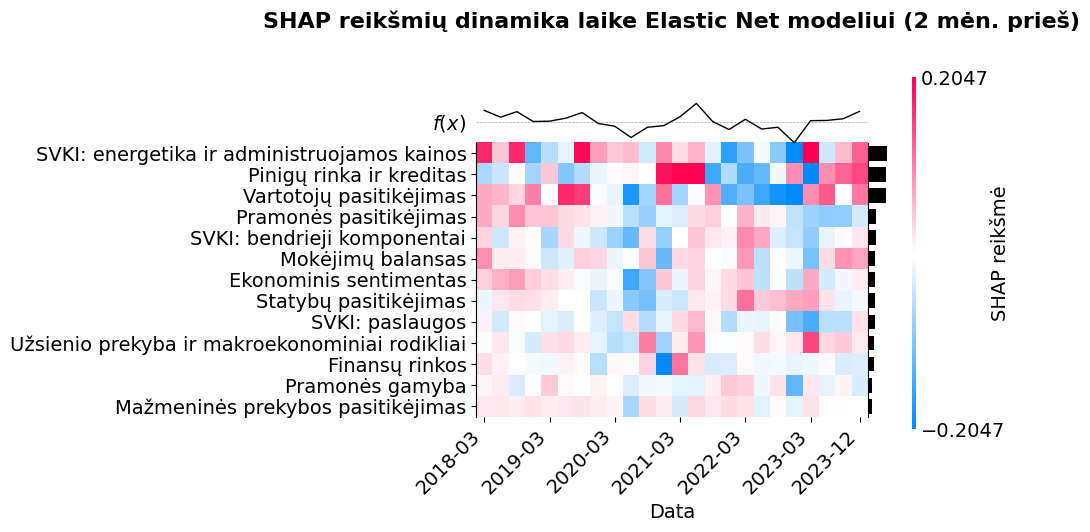

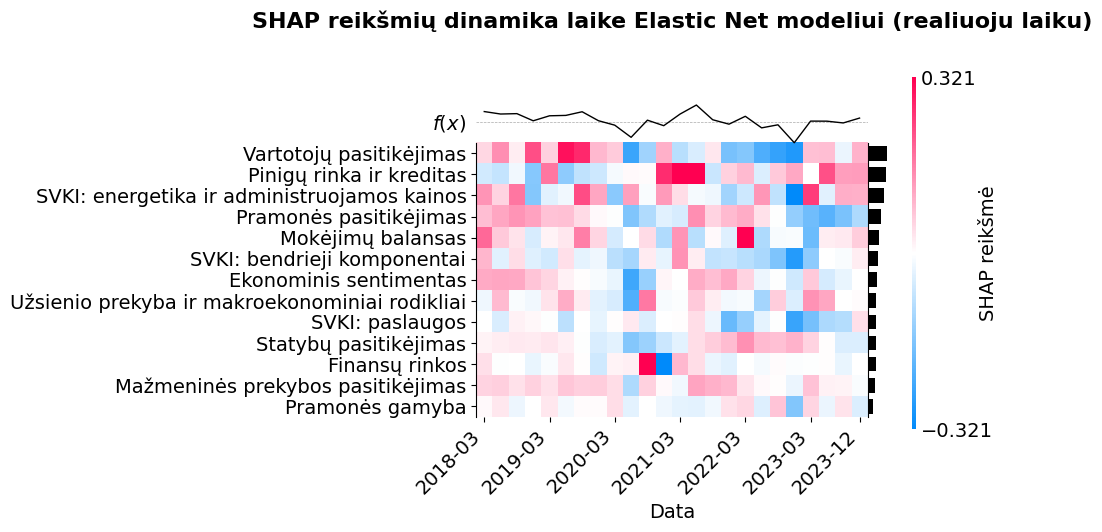

In [ ]:
target_lags_en = [-2, 0]
shap_accum_asp_en = {lag: [] for lag in target_lags_en}
base_accum_asp_en = {lag: [] for lag in target_lags_en}
date_accum_asp_en = {lag: [] for lag in target_lags_en}

disc_group_names_en = list(variable_groups_en.keys())


# Besiplečiantis langas
# Iteruojame per kiekvieną testavimo datą
for date in dates:
    train = test.loc[
        test.date <= str(pd.to_datetime(date) - pd.tseries.offsets.DateOffset(months=3))[:10], :
    ].copy()  # paimami visi duomenys iki trijų mėnesių prieš 

    transformed_train = mean_fill_dataset(train, train)
    transformed_train = flatten_data(transformed_train, target_variable, optimal_n_lags_en)
    transformed_train = transformed_train.loc[
        transformed_train.date.dt.month.isin([3, 6, 9, 12]), :
    ].dropna(subset=[target_variable]).reset_index(drop=True)

    model_en_ew = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('enet', ElasticNet(**clean_params_en, random_state=42, max_iter=20000, selection='random'))
    ])

    x_en = transformed_train.drop(["date", target_variable], axis=1)
    y_en = transformed_train[target_variable]
    model_en_ew.fit(x_en, y_en) # testavimo datai apmokomas modelis

    # Iteruojame per informacijos prieinamumo laikotarpius (-2, 0)
    for lag in target_lags_en:
        # Generuojami pseudo-realaus laiko testiniai duomenys pagal informacijos prieinamum1 tuo momentu
        tmp_data = gen_lagged_data(metadata, test, date, lag)
        tmp_data = mean_fill_dataset(train, tmp_data)
        tmp_data = flatten_data(tmp_data, target_variable, optimal_n_lags_en)

        x_test_en = tmp_data.loc[tmp_data.date == date, x_en.columns]

        if x_test_en.empty:
            continue

        #  Iš Pipeline paimami modleiavimo žingsniai
        imputer_ew = model_en_ew.named_steps['imputer']
        scaler_ew = model_en_ew.named_steps['scaler']
        enet_ew = model_en_ew.named_steps['enet']

        # Mokymo duomenys transformuojami rankiniu būdu pagal pipeline
        x_train_proc = pd.DataFrame(
            scaler_ew.transform(imputer_ew.transform(x_en)),
            columns=x_en.columns
        )
        explainer_en = shap.LinearExplainer(enet_ew, x_train_proc)

        # Testiniai duomenys transformuojami tais pačiais žingsniais
        x_test_imp = imputer_ew.transform(x_test_en)
        x_test_scl = pd.DataFrame(
            scaler_ew.transform(x_test_imp),
            columns=x_en.columns
        )

        shap_row = explainer_en(x_test_scl) # SHAP reikšmės vienai eilutei
        shap_values = shap_row.values[0]

        # SHAP reikšmės susumuojammos grupių lygmeniu
        shap_asp_row = []
        for group_name in disc_group_names_en:
            members = variable_groups_en[group_name]
            valid = [m for m in members if m in x_en.columns]
            if valid:
                idxs = [x_en.columns.tolist().index(m) for m in valid]
                shap_asp_row.append(np.sum(shap_values[idxs]))
            else:
                shap_asp_row.append(0.0)

        shap_accum_asp_en[lag].append(shap_asp_row)
        base_accum_asp_en[lag].append(shap_row.base_values[0])
        date_accum_asp_en[lag].append(date)

# Šilumos žemėlapio braižymas
for lag in target_lags_en:
    if not shap_accum_asp_en[lag]:
        continue

    exp_asp = shap.Explanation(
        values=np.array(shap_accum_asp_en[lag]),
        base_values=np.array(base_accum_asp_en[lag]),
        feature_names=disc_group_names_en
    )
    plt.rcParams.update({'font.size': 14})
    plt.figure(figsize=(12, 8))
    chronological_order = np.arange(len(shap_accum_asp_en[lag]))
    shap.plots.heatmap(exp_asp, max_display=15,
                       instance_order=chronological_order, show=False)
    

    main_ax = plt.gcf().axes[0]
    for ax in plt.gcf().axes:
        ax.tick_params(labelsize=14)
        ax.xaxis.label.set_size(14)
        ax.yaxis.label.set_size(14)
        ax.set_ylabel("SHAP reikšmė", fontsize=14)
        if ax == main_ax:
            ax.set_ylabel("")
        for text in ax.get_yticklabels():
            text.set_fontsize(14)
    step = 4
    ticks = np.arange(0, len(date_accum_asp_en[lag]), step)
    if (len(date_accum_asp_en[lag]) - 1) not in ticks:
        ticks = np.append(ticks, len(date_accum_asp_en[lag]) - 1)
    labels_x = [date_accum_asp_en[lag][i][:7] for i in ticks]
    main_ax.set_xticks(ticks)
    main_ax.set_xticklabels(labels_x, rotation=45, ha='right')
    main_ax.set_xlabel("Data")

    if lag == -2:
        horizontas = "(2 mėn. prieš)"
    elif lag == 0:
        horizontas = "(realiuoju laiku)"
    else:
        horizontas = f"(Horizontas h = {lag})"

    plt.title(
        f"SHAP reikšmių dinamika laike Elastic Net modeliui {horizontas}",
        pad=45, fontsize=16, fontweight="bold"
    )
    plt.subplots_adjust(bottom=0.22, left=0.35, right=0.90, top=0.85)
    plt.savefig(f'elasticnet_disc_aspect_heatmap_lag_{lag}.png', dpi=300, bbox_inches='tight')
    plt.show()

### Elastic Net lokali analizė

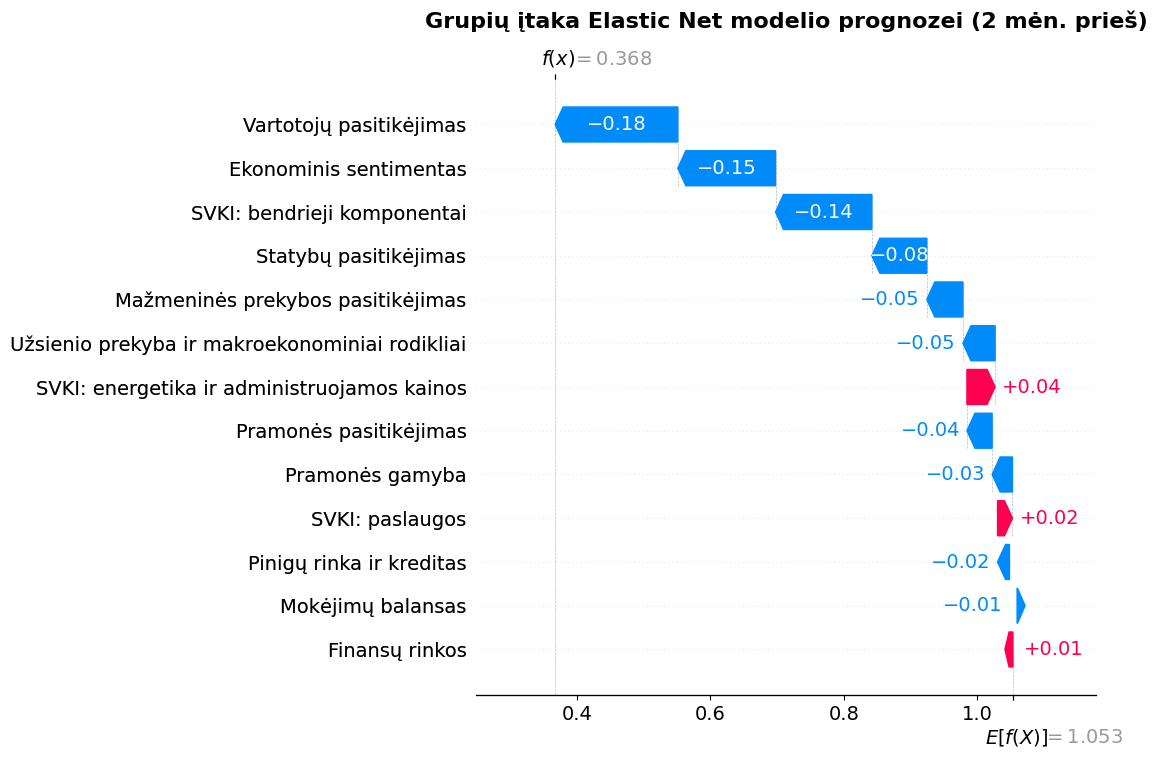

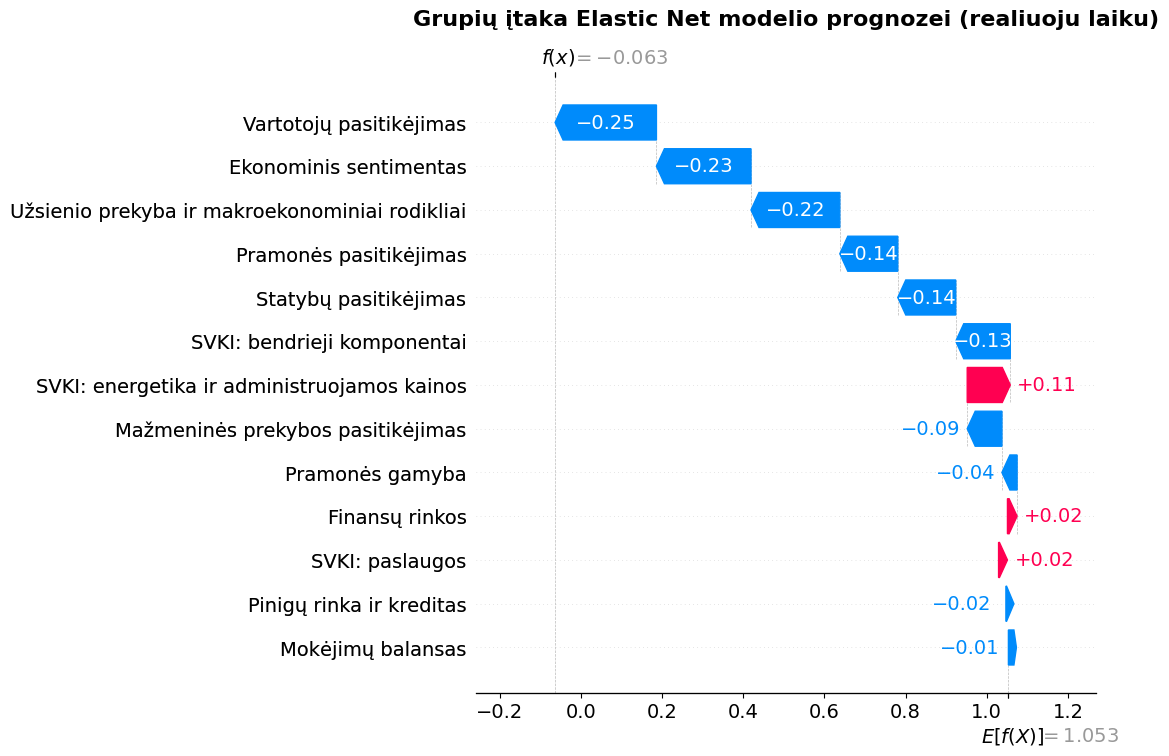

In [ ]:
if not hasattr(np, 'in1d'):
    np.in1d = np.isin

target_date = "2020-06-01"
target_date_ts = pd.to_datetime(target_date)
lags = [-2, 0]

# Krioklio grafikas grupės lygmeniu
for lag in lags:
    # Mokymo duomenys
    train_base = test.loc[
        test.date <= str(target_date_ts - pd.tseries.offsets.DateOffset(months=3))[:10], :
    ].copy()
    transformed_train = mean_fill_dataset(train_base, train_base)
    transformed_train = flatten_data(transformed_train, target_variable, optimal_n_lags_en)
    transformed_train = transformed_train.loc[
        transformed_train.date.dt.month.isin([3, 6, 9, 12]), :
    ].dropna(subset=[target_variable]).reset_index(drop=True)

    # Modelis
    model_en_local = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('enet', ElasticNet(**clean_params_en, max_iter=10000, selection='random'))
    ])
    x_en_local = transformed_train.drop(["date", target_variable], axis=1)
    y_en_local = transformed_train[target_variable]
    model_en_local.fit(x_en_local, y_en_local)

    # Testavimo informacijos prieinamumo laikotarpis
    tmp_data = gen_lagged_data(metadata, test, target_date_ts, lag)
    tmp_data = mean_fill_dataset(train_base, tmp_data)
    tmp_data = flatten_data(tmp_data, target_variable, optimal_n_lags_en)
    x_test_local = tmp_data.loc[tmp_data.date == target_date_ts, x_en_local.columns]

    if x_test_local.empty:
        continue

    # Explainer ir predict_parts
    imputer_ew = model_en_local.named_steps['imputer']
    x_local_imputed = pd.DataFrame(
        imputer_ew.transform(x_en_local),
        index=x_en_local.index,
        columns=x_en_local.columns
    )

    exp_local = dx.Explainer(model_en_local, data=x_local_imputed, y=y_en_local, verbose=False)
    asp_local = dx.Aspect(exp_local)

    pp = asp_local.predict_parts(
        new_observation=x_test_local,
        variable_groups=variable_groups_en,
        type='shap',
        B=100, #100
        random_state=42
    )

    # E. Krioklio grafikas su grupių pavadinimais
    result = pp.result.copy()
    result = result.sort_values('importance', key=abs, ascending=True)

    prediction_val = float(exp_local.predict(x_test_local)[0])
    base_val = prediction_val - float(pp.result['importance'].sum())

    shap_exp = shap.Explanation(
        values=result['importance'].values,
        base_values=base_val,
        data=None,
        feature_names=result['aspect_name'].tolist()
    )

    if lag == -2:
        horizontas_tekstas = "(2 mėn. prieš)"
    elif lag == 0:
        horizontas_tekstas = "(realiuoju laiku)"
    else:
        horizontas_tekstas = f"(Horizontas h = {lag})"

    plt.figure(figsize=(12, 8))
    shap.plots.waterfall(shap_exp, max_display=13, show=False)

    for ax in plt.gcf().axes:
        ax.tick_params(labelsize=14)
        ax.xaxis.label.set_size(14)
        ax.yaxis.label.set_size(14)
        for text in ax.get_yticklabels():
            text.set_fontsize(14)
        for text in ax.texts:
            text.set_fontsize(14)

    plt.title(
        f"Grupių įtaka Elastic Net modelio prognozei {horizontas_tekstas}",
        fontsize=16, pad=15, fontweight='bold'
    )

    plt.savefig(f'elasticnet_aspect_waterfall_{target_date}_{lag}.png', dpi=300, bbox_inches='tight')
    plt.show()

# XGBoost

In [ ]:
from xgboost import XGBRegressor

with open('xgboost/best_params_xgboost.json', 'r') as f:
    best_params_xgb = json.load(f)

optimal_n_lags_xgb = best_params_xgb.get("optimal_n_lags", 4)
xgb_inner_params = best_params_xgb.get("best_xgb_parameters", {})
clean_params_xgb = {k.replace('xgb__', ''): v for k, v in xgb_inner_params.items()}

test_xgb = data.loc[
    (data.date >= train_start_date) &
    (data.date <= test_end_date)
].reset_index(drop=True)

dates_xgb = (
    pd.date_range(test_start_date, test_end_date, freq="3MS")
    .strftime("%Y-%m-%d")
    .tolist()
)

actuals_xgb = list(test_xgb.loc[test_xgb.date.isin(dates_xgb), target_variable].values)

last_date_xgb = dates_xgb[-1]
print(f"Paskutinė testavimo data: {last_date_xgb}")

train_final_xgb = test_xgb.loc[
    test_xgb.date <= str(pd.to_datetime(last_date_xgb) - pd.tseries.offsets.DateOffset(months=3))[:10], :
].copy()

transformed_final_xgb = mean_fill_dataset(train_final_xgb, train_final_xgb)
transformed_final_xgb = flatten_data(transformed_final_xgb, target_variable, optimal_n_lags_xgb)
transformed_final_xgb = transformed_final_xgb.loc[
    transformed_final_xgb.date.dt.month.isin([3, 6, 9, 12]), :
].dropna(subset=[target_variable]).reset_index(drop=True)

x_final_xgb = transformed_final_xgb.drop(["date", target_variable], axis=1)
y_final_xgb = transformed_final_xgb[target_variable]

final_model_xgb = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('xgb', XGBRegressor(**clean_params_xgb, random_state=42, n_jobs=-1))
])
final_model_xgb.fit(x_final_xgb, y_final_xgb);

C:\Users\MigleV\AppData\Local\Temp\ipykernel_19624\1386483435.py:29: FutureWarning: The behavior of 'isin' with dtype=datetime64[ns] and castable values (e.g. strings) is deprecated. In a future version, these will not be considered matching by isin. Explicitly cast to the appropriate dtype before calling isin instead.
  actuals_xgb = list(test_xgb.loc[test_xgb.date.isin(dates_xgb), target_variable].values)


Paskutinė testavimo data: 2023-12-01


c:\Users\MigleV\Bakalauras\nowcast\lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


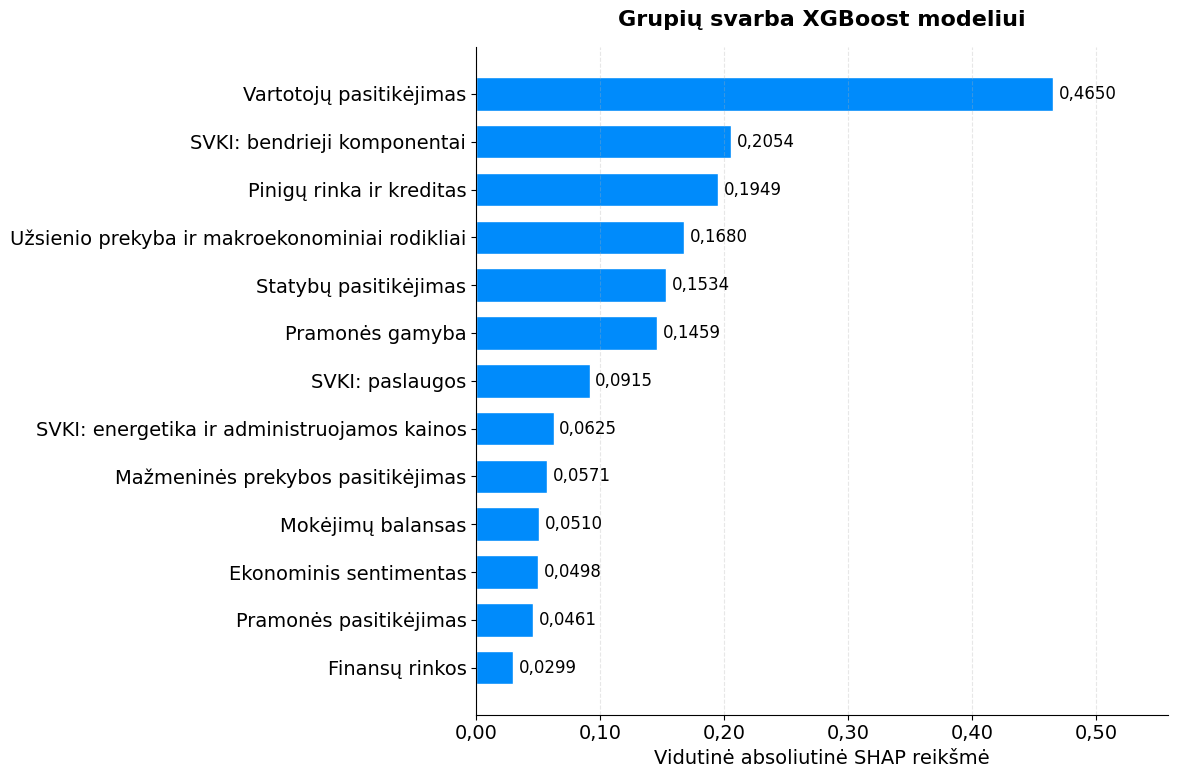

In [ ]:
# Iš Pipeline ištraukiamas imputer ir pritaikomas mokymo duomenims, užpildomos trūkstamos reikšmės
imputer_xgb = final_model_xgb.named_steps['imputer']
X_final_imputed_xgb = pd.DataFrame(
    imputer_xgb.transform(x_final_xgb),
    index=x_final_xgb.index,
    columns=x_final_xgb.columns
)

# Sukuriamos kintamųjų grupės pagal stulpelių pavadinimus
variable_groups_xgb = build_variable_groups(X_final_imputed_xgb.columns)

scaler_xgb = final_model_xgb.named_steps['scaler']
xgb_step = final_model_xgb.named_steps['xgb']

X_scaled_xgb = pd.DataFrame(
    scaler_xgb.transform(X_final_imputed_xgb),
    columns=X_final_imputed_xgb.columns,
    index=X_final_imputed_xgb.index
)

# Apskaičiuojamos SHAP reikšmės visiems mokymo stebėjimams. Gaunama matrica: eilutės = stebėjimai, stulpeliai = kintamieji.
shap_explainer_xgb = shap.TreeExplainer (xgb_step, X_scaled_xgb)
shap_values_xgb = shap_explainer_xgb(X_scaled_xgb).values
shap_df_xgb = pd.DataFrame(shap_values_xgb, columns=X_final_imputed_xgb.columns)

# SHAP reikšmės grupės lygyje
group_importance_xgb = {}
for group_name, features in variable_groups_xgb.items():
    valid_features = [f for f in features if f in shap_df_xgb.columns]
    if not valid_features:
        continue
    group_shap = shap_df_xgb[valid_features].sum(axis=1) # kiekvieno stebėjimo grupės SHAP reikšmė = narių SHAP suma
    group_importance_xgb[group_name] = group_shap.abs().mean()

importance_df_xgb = (
    pd.Series(group_importance_xgb)
    .sort_values(ascending=True)
    .reset_index()
    .rename(columns={"index": "aspect_name", 0: "mean_abs_shap"})
)

# Grafikas
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(
    range(len(importance_df_xgb)),
    importance_df_xgb["mean_abs_shap"],
    color="#008BFB",
    edgecolor="white",
    height=0.7
)
ax.set_yticks(range(len(importance_df_xgb)))
ax.set_yticklabels(importance_df_xgb["aspect_name"], fontsize=14)
ax.set_xlim(0, importance_df_xgb["mean_abs_shap"].max() * 1.20)

offset = importance_df_xgb["mean_abs_shap"].max() * 0.01
for i, row in importance_df_xgb.iterrows():
    ax.text(
        row["mean_abs_shap"] + offset,
        i,
        f'{row["mean_abs_shap"]:.4f}'.replace(".", ","),
        va="center", ha="left", fontsize=12
    )

ax.set_xlabel("Vidutinė absoliutinė SHAP reikšmė", fontsize=14)
ax.set_title("Grupių svarba XGBoost modeliui", fontsize=16, fontweight="bold", pad=15)
ax.tick_params(axis="x", labelsize=14)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}".replace(".", ",")))
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("xgb_aspect_shap.png", dpi=300, bbox_inches="tight")
plt.show()

### Spalvų intensyvumo žemėlapiai

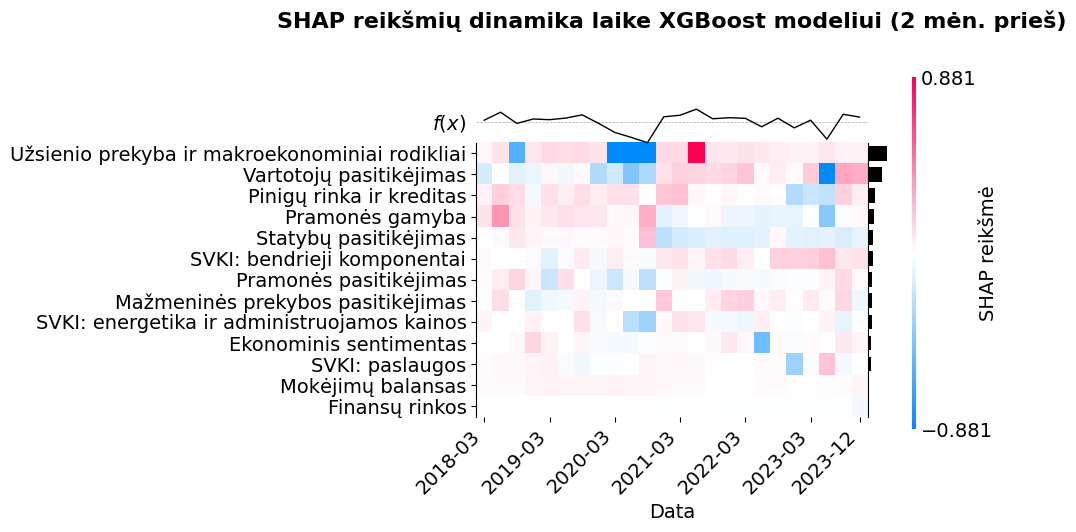

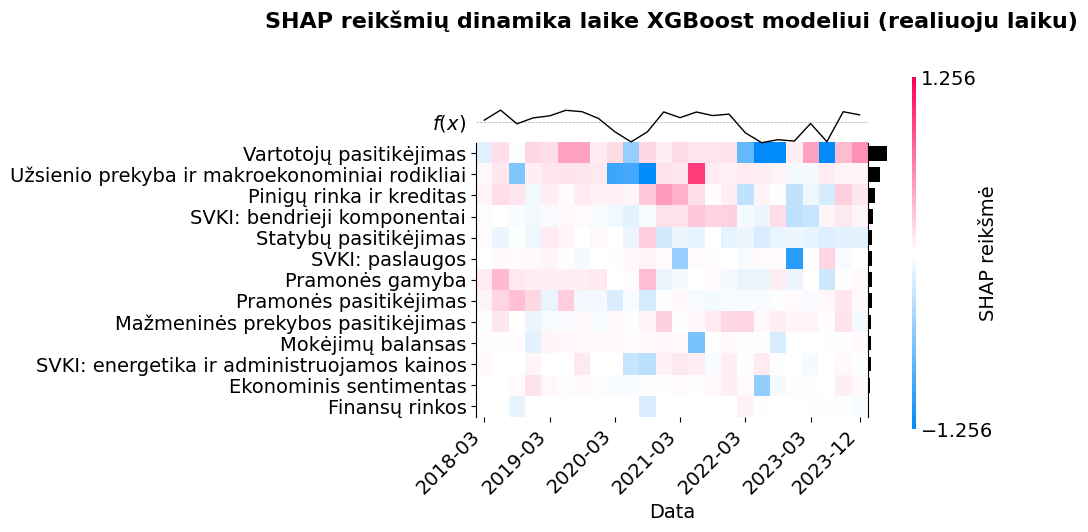

In [ ]:
target_lags_xgb = [-2, 0]
shap_accum_asp_xgb = {lag: [] for lag in target_lags_xgb}
base_accum_asp_xgb = {lag: [] for lag in target_lags_xgb}
date_accum_asp_xgb = {lag: [] for lag in target_lags_xgb}

disc_group_names_xgb = list(variable_groups_xgb.keys())

# Besipleciantis langas
for date in dates_xgb:
    train = test_xgb.loc[
        test_xgb.date <= str(pd.to_datetime(date) - pd.tseries.offsets.DateOffset(months=3))[:10], :
    ].copy()

    transformed_train = mean_fill_dataset(train, train)
    transformed_train = flatten_data(transformed_train, target_variable, optimal_n_lags_xgb)
    transformed_train = transformed_train.loc[
        transformed_train.date.dt.month.isin([3, 6, 9, 12]), :
    ].dropna(subset=[target_variable]).reset_index(drop=True)

    model_xgb_ew = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('xgb', XGBRegressor(**clean_params_xgb, random_state=42, n_jobs=-1))
    ])

    x_xgb = transformed_train.drop(["date", target_variable], axis=1)
    y_xgb = transformed_train[target_variable]
    model_xgb_ew.fit(x_xgb, y_xgb)

    for lag in target_lags_xgb:
        tmp_data = gen_lagged_data(metadata, test_xgb, date, lag)
        tmp_data = mean_fill_dataset(train, tmp_data)
        tmp_data = flatten_data(tmp_data, target_variable, optimal_n_lags_xgb)

        x_test_xgb = tmp_data.loc[tmp_data.date == date, x_xgb.columns]

        if x_test_xgb.empty:
            continue

        imputer_ew = model_xgb_ew.named_steps['imputer']
        scaler_ew = model_xgb_ew.named_steps['scaler']
        xgb_ew = model_xgb_ew.named_steps['xgb']

        x_train_proc = pd.DataFrame(
            scaler_ew.transform(imputer_ew.transform(x_xgb)),
            columns=x_xgb.columns
        )
        explainer_xgb = shap.TreeExplainer(xgb_ew, x_train_proc)

        x_test_imp = imputer_ew.transform(x_test_xgb)
        x_test_scl = pd.DataFrame(
            scaler_ew.transform(x_test_imp),
            columns=x_xgb.columns
        )

        shap_row = explainer_xgb(x_test_scl)
        shap_values = shap_row.values[0]

        shap_asp_row = []
        for group_name in disc_group_names_xgb:
            members = variable_groups_xgb[group_name]
            valid = [m for m in members if m in x_xgb.columns]
            if valid:
                idxs = [x_xgb.columns.tolist().index(m) for m in valid]
                shap_asp_row.append(np.sum(shap_values[idxs]))
            else:
                shap_asp_row.append(0.0)

        shap_accum_asp_xgb[lag].append(shap_asp_row)
        base_accum_asp_xgb[lag].append(shap_row.base_values[0])
        date_accum_asp_xgb[lag].append(date)

# Spalvų intensyvumo žemėlapio braižymas
for lag in target_lags_xgb:
    if not shap_accum_asp_xgb[lag]:
        continue

    exp_asp = shap.Explanation(
        values=np.array(shap_accum_asp_xgb[lag]),
        base_values=np.array(base_accum_asp_xgb[lag]),
        feature_names=disc_group_names_xgb
    )

    plt.rcParams.update({'font.size': 14})
    plt.figure(figsize=(12, 8))
    chronological_order = np.arange(len(shap_accum_asp_xgb[lag]))
    shap.plots.heatmap(exp_asp, max_display=15,
                       instance_order=chronological_order, show=False)

    main_ax = plt.gcf().axes[0]
    for ax in plt.gcf().axes:
        ax.tick_params(labelsize=14)
        ax.xaxis.label.set_size(14)
        ax.yaxis.label.set_size(14)
        ax.set_ylabel("SHAP reikšmė", fontsize=14)
        if ax == main_ax:
            ax.set_ylabel("")
        for text in ax.get_yticklabels():
            text.set_fontsize(14)

    step = 4
    ticks = np.arange(0, len(date_accum_asp_xgb[lag]), step)
    if (len(date_accum_asp_xgb[lag]) - 1) not in ticks:
        ticks = np.append(ticks, len(date_accum_asp_xgb[lag]) - 1)
    labels_x = [date_accum_asp_xgb[lag][i][:7] for i in ticks]
    main_ax.set_xticks(ticks)
    main_ax.set_xticklabels(labels_x, rotation=45, ha='right')
    main_ax.set_xlabel("Data")

    if lag == -2:
        horizontas = "(2 mėn. prieš)"
    elif lag == 0:
        horizontas = "(realiuoju laiku)"
    else:
        horizontas = f"(Horizontas h = {lag})"

    plt.title(
        f"SHAP reikšmių dinamika laike XGBoost modeliui {horizontas}",
        pad=45, fontsize=16, fontweight="bold"
    )
    plt.subplots_adjust(bottom=0.22, left=0.35, right=0.90, top=0.85)
    #plt.savefig(f'xgboost_disc_aspect_heatmap_lag_{lag}.png', dpi=300, bbox_inches='tight')
    plt.show()

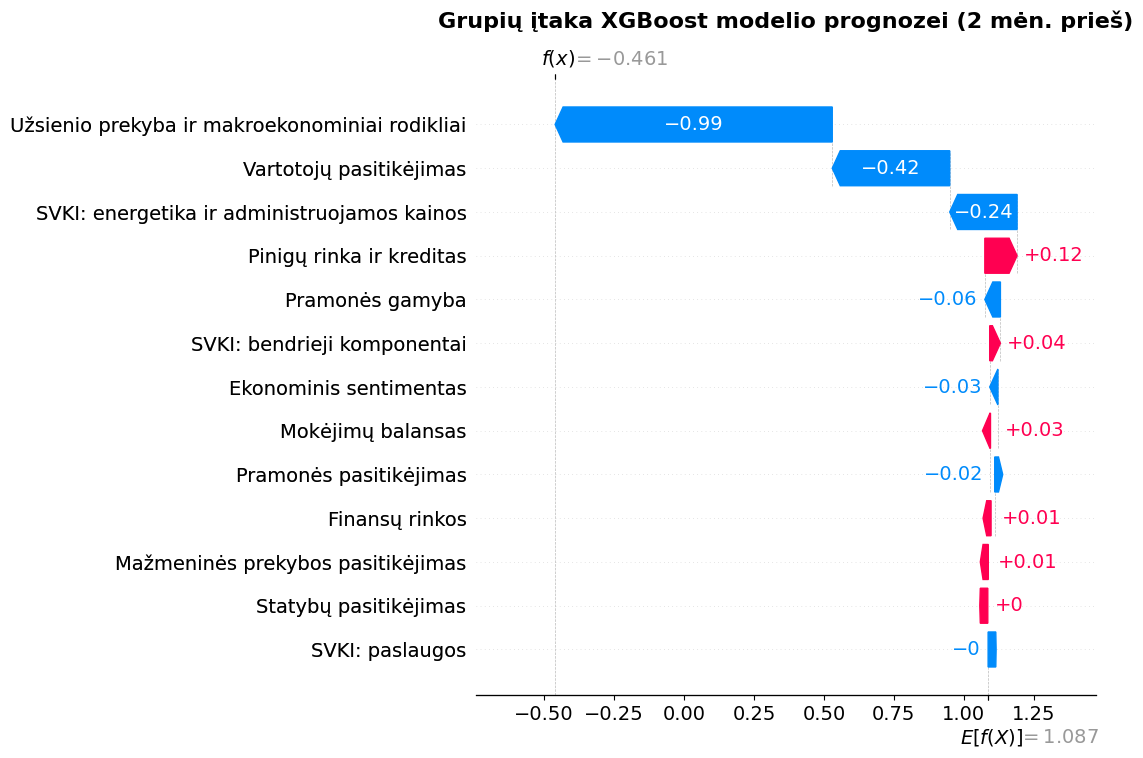

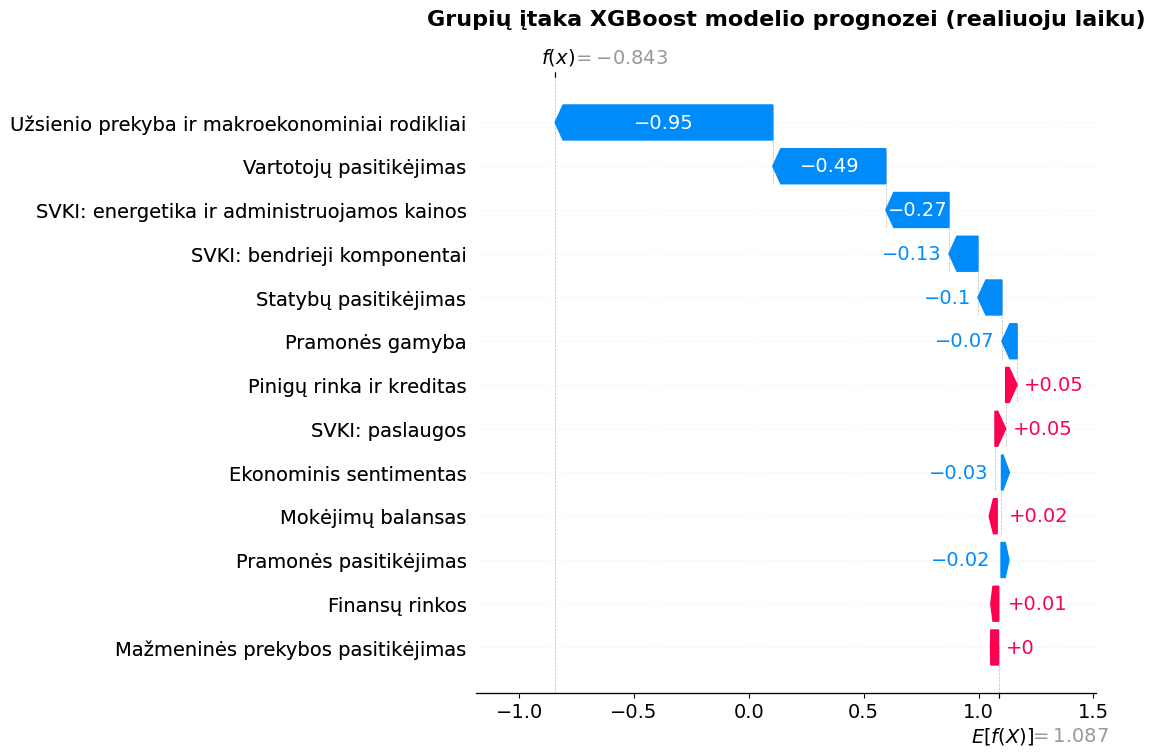

In [ ]:
import numpy as np
if not hasattr(np, 'in1d'):
    np.in1d = np.isin

target_date = "2020-06-01"
target_date_ts = pd.to_datetime(target_date)
local_lags = [-2, 0]


for lag in local_lags:
    train_base = test_xgb.loc[
        test_xgb.date <= str(target_date_ts - pd.tseries.offsets.DateOffset(months=3))[:10], :
    ].copy()
    transformed_train = mean_fill_dataset(train_base, train_base)
    transformed_train = flatten_data(transformed_train, target_variable, optimal_n_lags_xgb)
    transformed_train = transformed_train.loc[
        transformed_train.date.dt.month.isin([3, 6, 9, 12]), :
    ].dropna(subset=[target_variable]).reset_index(drop=True)


    model_xgb_local = Pipeline([
        ('imputer', SimpleImputer(strategy='mean')),
        ('scaler', StandardScaler()),
        ('xgb', XGBRegressor(**clean_params_xgb, random_state=42, n_jobs=-1))
    ])
    x_xgb_local = transformed_train.drop(["date", target_variable], axis=1)
    y_xgb_local = transformed_train[target_variable]
    model_xgb_local.fit(x_xgb_local, y_xgb_local)

    tmp_data = gen_lagged_data(metadata, test_xgb, target_date_ts, lag)
    tmp_data = mean_fill_dataset(train_base, tmp_data)
    tmp_data = flatten_data(tmp_data, target_variable, optimal_n_lags_xgb)
    x_test_local = tmp_data.loc[tmp_data.date == target_date_ts, x_xgb_local.columns]

    if x_test_local.empty:
        continue

    imputer_ew = model_xgb_local.named_steps['imputer']
    x_local_imputed = pd.DataFrame(
        imputer_ew.transform(x_xgb_local),
        index=x_xgb_local.index,
        columns=x_xgb_local.columns
    )

    exp_local = dx.Explainer(model_xgb_local, data=x_local_imputed, y=y_xgb_local, verbose=False)
    asp_local = dx.Aspect(exp_local)

    pp = asp_local.predict_parts(
        new_observation=x_test_local,
        variable_groups=variable_groups_xgb,
        type='shap',
        B=100,
        random_state=42
    )


    result = pp.result.copy()
    result = result.sort_values('importance', key=abs, ascending=True)

    prediction_val = float(exp_local.predict(x_test_local)[0])
    base_val = prediction_val - float(pp.result['importance'].sum())

    shap_exp = shap.Explanation(
        values=result['importance'].values,
        base_values=base_val,
        data=None,
        feature_names=result['aspect_name'].tolist()
    )

    if lag == -2:
        horizontas_tekstas = "(2 mėn. prieš)"
    elif lag == 0:
        horizontas_tekstas = "(realiuoju laiku)"
    else:
        horizontas_tekstas = f"(Horizontas h = {lag})"

    plt.figure(figsize=(12, 8))
    shap.plots.waterfall(shap_exp, max_display=13, show=False)

    for ax in plt.gcf().axes:
        ax.tick_params(labelsize=14)
        ax.xaxis.label.set_size(14)
        ax.yaxis.label.set_size(14)
        for text in ax.get_yticklabels():
            text.set_fontsize(14)
        for text in ax.texts:
            text.set_fontsize(14)
    plt.title(
        f"Grupių įtaka XGBoost modelio prognozei {horizontas_tekstas}",
        fontsize=16, pad=15, fontweight='bold'
    )

    plt.savefig(f'xgboost_aspect_waterfall_{target_date}_{lag}.png', dpi=300, bbox_inches='tight')
    plt.show()